In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the new dataset (Make sure your new CSV file is in the same directory)
df = pd.read_csv('lahore_house_listings_zameen.csv')

# Display the first 5 rows to check columns
print("--- First 5 Rows of New Dataset ---")
display(df.head())

# Display dataset info
print("\n--- Dataset Information ---")
df.info()

--- First 5 Rows of New Dataset ---


,Title,Location,Type,Price,Area,Bedrooms,Bathrooms,Purpose,Date Posted,Built Year,...,Furnished,Gym,Study Room,Drawing Room,Dining Room,Lawn/Garden,Swimming Pool,Electricity Backup,Lounge/Sitting Room,Link
0,ACTUALLY 25 MARLA DOUBLE UNIT LUXURIOUS & GRAC...,"DHA Phase 6 - Block F, DHA Phase 6, DHA Defenc...",House,8.15 Crore,1 Kanal,6,7,For Sale,2025-07-27,2024.0,...,True,True,True,True,True,True,True,True,True,https://www.zameen.com/Property/dha_phase_6_dh...
1,3 Years Installment Plan Luxury Brand New Hous...,"Park View City, Lahore, Punjab",House,1.5 Crore,5 Marla,4,5,For Sale,2025-07-25,2012.0,...,True,False,False,True,True,True,False,True,True,https://www.zameen.com/Property/lahore_park_vi...
2,5 Marla Luxury House In Rose Block Of Park-Vie...,"Park View City - Rose Block, Park View City, L...",House,2.4 Crore,5 Marla,4,4,For Sale,2025-07-25,2025.0,...,True,True,True,True,True,True,True,True,True,https://www.zameen.com/Property/park_view_city...
3,Full Basement 1 kanal Brand New Luxury House N...,"DHA Phase 7 - Block S, DHA Phase 7, DHA Defenc...",House,7.5 Crore,1 Kanal,5,6,For Sale,2025-07-25,2024.0,...,False,True,True,True,True,True,True,True,True,https://www.zameen.com/Property/dha_phase_7_dh...
4,1 Kanal Dream Home With Private Pool In DHA Ph...,"DHA Phase 6, DHA Defence, Lahore, Punjab",House,6.95 Crore,1 Kanal,6,7,For Sale,2025-07-25,2024.0,...,True,True,True,True,True,True,True,True,True,https://www.zameen.com/Property/dha_defence_dh...



--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Title                18249 non-null  str    
 1   Location             18249 non-null  str    
 2   Type                 18249 non-null  str    
 3   Price                18249 non-null  str    
 4   Area                 18249 non-null  str    
 5   Bedrooms             18249 non-null  str    
 6   Bathrooms            18249 non-null  str    
 7   Purpose              18249 non-null  str    
 8   Date Posted          11319 non-null  str    
 9   Built Year           13497 non-null  float64
 10  Kitchens             18249 non-null  int64  
 11  Store Rooms          18249 non-null  int64  
 12  Servant Quarters     18249 non-null  int64  
 13  Furnished            18249 non-null  bool   
 14  Gym                  18249 non-null  bool   
 15  Study Room        

--- EDA & Data Cleaning Summary ---
Original Dataset Shape: (18249, 25)
Cleaned Dataset Shape: (18249, 25)


,Clean_Price,Clean_Area_Marla
count,1.824900e+04,18249.000000
mean,5.771182e+07,12.511776
std,7.178234e+07,12.804543
min,1.000000e+00,0.000000
25%,2.050000e+07,5.000000
50%,3.550000e+07,10.000000
75%,7.100000e+07,20.000000
max,9.000000e+08,480.000000


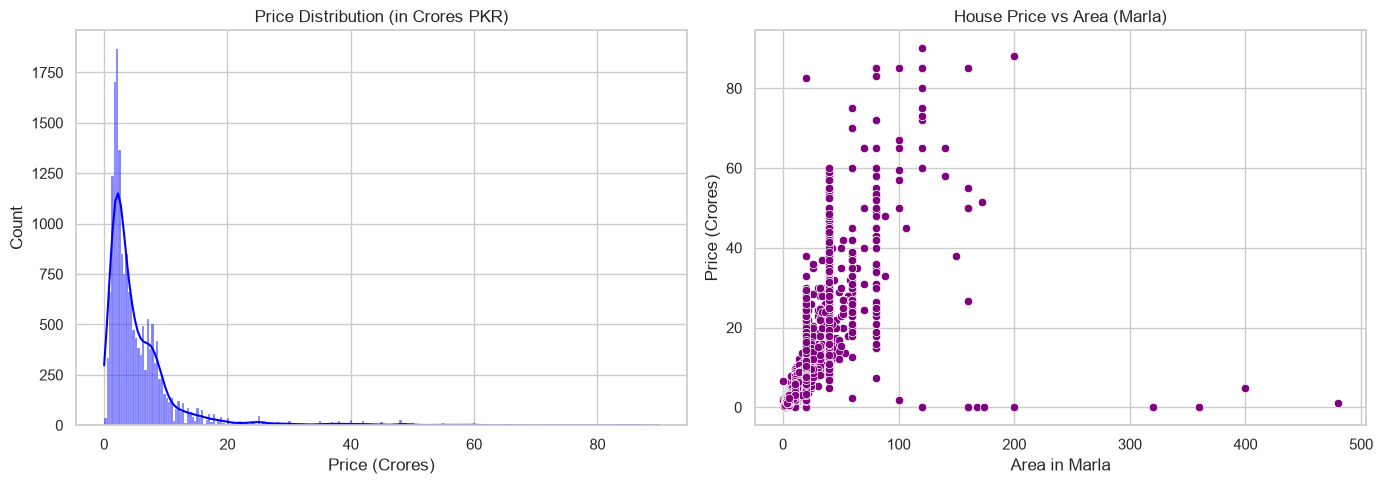

In [5]:
# ==========================================
# STEP 02 & 03: COMPLETE DATA CLEANING & EDA
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Load Dataset
df = pd.read_csv('lahore_house_listings_zameen.csv')

# 2. Cleaning Functions for Price and Area
def clean_price(price_str):
    if pd.isna(price_str):
        return np.nan
    price_str = str(price_str).lower()
    num = float(re.findall(r"[\d.]+", price_str)[0])
    if 'crore' in price_str:
        return num * 10_000_000
    elif 'lakh' in price_str:
        return num * 100_000
    return num

def clean_area_to_marla(area_str):
    if pd.isna(area_str):
        return np.nan
    area_str = str(area_str).lower()
    nums = re.findall(r"[\d.]+", area_str)
    if not nums:
        return np.nan
    num = float(nums[0])
    if 'kanal' in area_str:
        return num * 20
    elif 'marla' in area_str:
        return num
    return num

# Apply cleaning
df['Clean_Price'] = df['Price'].apply(clean_price)
df['Clean_Area_Marla'] = df['Area'].apply(clean_area_to_marla)

# Drop nulls in essential columns
df_clean = df.dropna(subset=['Clean_Price', 'Clean_Area_Marla', 'Bedrooms', 'Bathrooms']).copy()

print("--- EDA & Data Cleaning Summary ---")
print(f"Original Dataset Shape: {df.shape}")
print(f"Cleaned Dataset Shape: {df_clean.shape}")
display(df_clean[['Clean_Price', 'Clean_Area_Marla', 'Bedrooms', 'Bathrooms']].describe())

# 3. Visual Plots for EDA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Price Distribution
sns.histplot(df_clean['Clean_Price'] / 10_000_000, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Price Distribution (in Crores PKR)')
axes[0].set_xlabel('Price (Crores)')

# Plot 2: Price vs Area
sns.scatterplot(x='Clean_Area_Marla', y=df_clean['Clean_Price'] / 10_000_000, data=df_clean, ax=axes[1], color='purple')
axes[1].set_title('House Price vs Area (Marla)')
axes[1].set_xlabel('Area in Marla')
axes[1].set_ylabel('Price (Crores)')

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# STEP 04 & 05: PREPROCESSING & FEATURE ENGINEERING
# ==========================================

# 1. Select relevant features for the model
# We will use Area in Marla, Bedrooms, Bathrooms, and extract Location/Society if needed
features_df = df_clean[['Clean_Area_Marla', 'Bedrooms', 'Bathrooms', 'Location']].copy()

# Feature Engineering: Create a total rooms feature
features_df['Total_Rooms'] = features_df['Bedrooms'] + features_df['Bathrooms']

# Extract main city/area or encode location categories
# Let's use One-Hot Encoding for the top locations to keep it clean
top_locations = features_df['Location'].value_counts().head(10).index.tolist()
features_df['Mapped_Location'] = features_df['Location'].apply(lambda x: x if x in top_locations else 'Other')

# One-hot encode the mapped locations
features_encoded = pd.get_dummies(features_df, columns=['Mapped_Location'], drop_first=True)

# Drop original non-numeric columns
X = features_encoded.drop(columns=['Location'])
y = df_clean['Clean_Price']

print("--- Preprocessing & Feature Engineering Completed ---")
print(f"Features Shape (X): {X.shape}")
print(f"Target Shape (y): {y.shape}")

--- Preprocessing & Feature Engineering Completed ---
Features Shape (X): (18249, 14)
Target Shape (y): (18249,)


In [7]:
# ==========================================
# STEP 06: SPLIT THE DATASET (VERSION 2)
# ==========================================

from sklearn.model_selection import train_test_split

# Partition the preprocessed data into 80% Training and 20% Testing sets
# random_state ensures reproducibility so the split remains identical every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Dataset Splitting Completed ---")
print(f"Total Training Samples (X_train): {X_train.shape[0]}")
print(f"Total Testing Samples (X_test): {X_test.shape[0]}")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

--- Dataset Splitting Completed ---
Total Training Samples (X_train): 14599
Total Testing Samples (X_test): 3650
Training Features Shape: (14599, 14)
Testing Features Shape: (3650, 14)


In [9]:
# ==========================================
# FIX & RETRAIN: STEP 07 & 08
# ==========================================

from sklearn.ensemble import RandomForestRegressor

# 1. Ensure all features in X, X_train, and X_test are strictly numeric
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# 2. Model Selection
model_v2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("--- Model Selected: Random Forest Regressor ---")

# 3. Model Training
print("Training the model on the new dataset... Please wait a moment.")
model_v2.fit(X_train, y_train)

print("--- Model Training Completed Successfully! ---")

--- Model Selected: Random Forest Regressor ---
Training the model on the new dataset... Please wait a moment.
--- Model Training Completed Successfully! ---


In [10]:
# ==========================================================
# STEP 09, 10 & 11: EVALUATION, TUNING, TESTING & SAVING
# ==========================================================

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import pickle

# --- STEP 09: Model Evaluation on Test Data ---
y_pred = model_v2.predict(X_test)
initial_r2 = r2_score(y_test, y_pred)
initial_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- Step 09: Initial Evaluation Results ---")
print(f"R2 Score: {initial_r2:.4f}")
print(f"RMSE: PKR {initial_rmse:,.2f}\n")


# --- STEP 10: Hyperparameter Tuning (Optimizing Performance) ---
print("--- Step 10: Optimizing Hyperparameters ---")
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

random_search = RandomizedSearchCV(
    estimator=model_v2,
    param_distributions=param_grid,
    n_iter=3,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_model_v2 = random_search.best_estimator_

print(f"Best Parameters Found: {random_search.best_params_}\n")


# --- STEP 11: Final Testing & Saving the Model ---
final_y_pred = best_model_v2.predict(X_test)
final_r2 = r2_score(y_test, final_y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_y_pred))

print("--- Step 11: Final Model Testing & Saving ---")
print(f"Final Tuned R2 Score: {final_r2:.4f}")
print(f"Final Tuned RMSE: PKR {final_rmse:,.2f}")

# Save the new version 2 model into a pickle file
model_filename_v2 = 'house_price_model_v2.pkl'
with open(model_filename_v2, 'wb') as file:
    pickle.dump(best_model_v2, file)

print(f"\n--- Success! ---")
print(f"New Model successfully saved as '{model_filename_v2}' in your project directory.")

--- Step 09: Initial Evaluation Results ---
R2 Score: 0.7516
RMSE: PKR 35,724,554.09

--- Step 10: Optimizing Hyperparameters ---
Best Parameters Found: {'n_estimators': 150, 'min_samples_split': 2, 'max_depth': 10}

--- Step 11: Final Model Testing & Saving ---
Final Tuned R2 Score: 0.7546
Final Tuned RMSE: PKR 35,509,508.34

--- Success! ---
New Model successfully saved as 'house_price_model_v2.pkl' in your project directory.


In [11]:
# ==========================================
# TESTING THE NEW MODEL (VERSION 2)
# ==========================================

import pandas as pd
import pickle

# 1. Load the new saved model
with open('house_price_model_v2.pkl', 'rb') as file:
    best_model_v2 = pickle.load(file)

# 2. Input details for the Al-Kabir Town House
# Note: Ensure the columns match the ones used in X (the training features)
property_data = {
    'Clean_Area_Marla': [3.0],
    'Bedrooms': [3],
    'Bathrooms': [4],
    'Total_Rooms': [7]  # (3+4)
}

# Create a DataFrame and fill missing location columns with 0
test_df = pd.DataFrame(property_data)
# Add the location columns that the model expects (all 0 for this test)
for col in X.columns:
    if col not in test_df.columns:
        test_df[col] = 0

# Ensure column order matches the training data
test_df = test_df[X.columns]

# 3. Predict the price
predicted_price_v2 = best_model_v2.predict(test_df)

# Output
print("--- New Model (Version 2) Prediction Result ---")
print(f"Property: 3 Marla House in Al-Kabir Town, Lahore")
print(f"Model Predicted Price: PKR {predicted_price_v2[0]:,.2f}")
print(f"Internet Demand: PKR 11,700,000.00 (1.17 Crore)")

--- New Model (Version 2) Prediction Result ---
Property: 3 Marla House in Al-Kabir Town, Lahore
Model Predicted Price: PKR 9,674,553.16
Internet Demand: PKR 11,700,000.00 (1.17 Crore)


In [13]:
# ==========================================
# TEST 2: Lake City 5 Marla House (Crore Format)
# ==========================================

property_data_2 = {
    'Clean_Area_Marla': [5.0],
    'Bedrooms': [4],
    'Bathrooms': [5],
    'Total_Rooms': [4 + 5]
}

test_df_2 = pd.DataFrame(property_data_2)
for col in X.columns:
    if col not in test_df_2.columns:
        test_df_2[col] = 0
test_df_2 = test_df_2[X.columns]

predicted_price_2 = best_model_v2.predict(test_df_2)[0]
price_in_crore = predicted_price_2 / 10_000_000

print("--- Test 2 Prediction Result ---")
print(f"Property: 5 Marla House in Lake City, Lahore (4 Beds, 5 Baths)")
print(f"Model Predicted Price: PKR {price_in_crore:.2f} Crore")
print(f"Internet Demand: PKR 2.95 Crore")

--- Test 2 Prediction Result ---
Property: 5 Marla House in Lake City, Lahore (4 Beds, 5 Baths)
Model Predicted Price: PKR 1.66 Crore
Internet Demand: PKR 2.95 Crore


In [14]:
# ==========================================
# TEST 3: Bahria Enclave Islamabad 11 Marla House
# ==========================================

property_data_3 = {
    'Clean_Area_Marla': [11.0],
    'Bedrooms': [5],
    'Bathrooms': [6],
    'Total_Rooms': [5 + 6]
}

test_df_3 = pd.DataFrame(property_data_3)
for col in X.columns:
    if col not in test_df_3.columns:
        test_df_3[col] = 0
test_df_3 = test_df_3[X.columns]

predicted_price_3 = best_model_v2.predict(test_df_3)[0]
price_in_crore_3 = predicted_price_3 / 10_000_000

print("--- Test 3 Prediction Result ---")
print(f"Property: 11 Marla House in Islamabad (5 Beds, 6 Baths)")
print(f"Model Predicted Price: PKR {price_in_crore_3:.2f} Crore")
print(f"Internet Demand: PKR 6.10 Crore")

--- Test 3 Prediction Result ---
Property: 11 Marla House in Islamabad (5 Beds, 6 Baths)
Model Predicted Price: PKR 4.22 Crore
Internet Demand: PKR 6.10 Crore


In [15]:
# ==========================================
# TEST 4: Valencia Town Lahore 56 Marla House
# ==========================================

property_data_4 = {
    'Clean_Area_Marla': [56.0],
    'Bedrooms': [7],
    'Bathrooms': [7],
    'Total_Rooms': [7 + 7]
}

test_df_4 = pd.DataFrame(property_data_4)
for col in X.columns:
    if col not in test_df_4.columns:
        test_df_4[col] = 0
test_df_4 = test_df_4[X.columns]

predicted_price_4 = best_model_v2.predict(test_df_4)[0]
price_in_crore_4 = predicted_price_4 / 10_000_000

print("--- Test 4 Prediction Result ---")
print(f"Property: 56 Marla House in Valencia Town, Lahore (7 Beds, 7 Baths)")
print(f"Model Predicted Price: PKR {price_in_crore_4:.2f} Crore")
print(f"Internet Demand: PKR 17.49 Crore")

--- Test 4 Prediction Result ---
Property: 56 Marla House in Valencia Town, Lahore (7 Beds, 7 Baths)
Model Predicted Price: PKR 25.07 Crore
Internet Demand: PKR 17.49 Crore


In [16]:
# ==========================================
# TEST 5: DHA 9 Town Lahore 5.5 Marla House
# ==========================================

property_data_5 = {
    'Clean_Area_Marla': [5.5],
    'Bedrooms': [4],
    'Bathrooms': [5],
    'Total_Rooms': [4 + 5]
}

test_df_5 = pd.DataFrame(property_data_5)
for col in X.columns:
    if col not in test_df_5.columns:
        test_df_5[col] = 0
test_df_5 = test_df_5[X.columns]

predicted_price_5 = best_model_v2.predict(test_df_5)[0]
price_in_crore_5 = predicted_price_5 / 10_000_000

print("--- Test 5 Prediction Result ---")
print(f"Property: 5.5 Marla House in DHA 9 Town, Lahore (4 Beds, 5 Baths)")
print(f"Model Predicted Price: PKR {price_in_crore_5:.2f} Crore")
print(f"Internet Demand: PKR 2.95 Crore")

--- Test 5 Prediction Result ---
Property: 5.5 Marla House in DHA 9 Town, Lahore (4 Beds, 5 Baths)
Model Predicted Price: PKR 2.01 Crore
Internet Demand: PKR 2.95 Crore
